In [1]:
import pandas as pd
import re
import json


input_path = "jaemin_20251124_2_.txt"  

with open(input_path, "r", encoding="utf-8") as f:
    text = f.read()

pattern = r"(\/[^\n]+\/(normal|abnormal)\/[^\n]+)\s*[\s\S]*?(?:```json\s*([\s\S]*?)\s*```|(\{[\s\S]*?\}))"
matches = re.findall(pattern, text, re.DOTALL)

rows = []

for match in matches:
    
    path, truth, json_block, json_raw = match
    json_str = json_block if json_block else json_raw
    
    try:
        data = json.loads(json_str)

        is_scam = bool(data.get("is_scam"))

        if (is_scam and truth == "abnormal") or (not is_scam and truth == "normal"):
            result = True
        else:
            result = False

        rows.append({
            "filename": path.split("/")[-1].strip(),
            "truth": truth,
            "is_scam": data.get("is_scam"),
            "result": result,
            "is_correct": data.get("is_scam"),
            "confidence": data.get("confidence"),
            "risk": data.get("risk"),
            "evidence": "; ".join(data.get("evidence", [])),
            "explanation": data.get("explanation"),            
        })
    except json.JSONDecodeError as e:
        print(f"JSON 파싱 오류 발생 ({path}): {e}")

df = pd.DataFrame(rows, columns=["filename", "truth", "is_scam", "result", "confidence", "risk", "evidence", "explanation"])

output_path = "scam_results.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"CSV 파일 생성 완료: {output_path}")
print(df)


CSV 파일 생성 완료: scam_results.csv
    filename     truth  is_scam  result  confidence  risk  \
0   0025.mp4    normal     True   False        0.95  high   
1   0011.mp4    normal    False    True        0.95   low   
2   0024.mp4    normal    False    True        0.95   low   
3   0004.mp4    normal    False    True        0.95   low   
4   0001.mp4    normal    False    True        0.95   low   
5   0006.mp4    normal    False    True        0.95   low   
6   0016.mp4    normal    False    True        0.95   low   
7   0005.mp4    normal    False    True        0.95   low   
8   0018.mp4    normal    False    True        0.95   low   
9   0023.mp4    normal    False    True        0.95   low   
10  0007.mp4    normal    False    True        0.95   low   
11  0014.mp4    normal    False    True        0.95   low   
12  0021.mp4    normal    False    True        0.95   low   
13  0027.mp4    normal    False    True        0.95   low   
14  0010.mp4    normal    False    True        0.95   

In [6]:
df.groupby(["truth", "result"]).agg({"filename":"count"})

filename
truth    result          
abnormal False         23
         True           3
normal   False          2
         True          25

In [7]:
df[df['result']==True]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
1,0011.mp4,normal,False,True,0.95,low,할바하게 되면 하는 것; 이어폰 빼고,The video provides tips on what to do and not ...
2,0024.mp4,normal,False,True,0.95,low,normal content; product demonstration,The video shows a person demonstrating the use...
3,0004.mp4,normal,False,True,0.95,low,request for money; external funnel,The video provides a humorous and informative ...
4,0001.mp4,normal,False,True,0.95,low,이거 실耗나?,The content discusses the challenges of part-t...
5,0006.mp4,normal,False,True,0.95,low,50대 근판리업후기,The content appears to be a personal review or...
6,0016.mp4,normal,False,True,0.95,low,cube solving; scam detector,The video shows a person skillfully manipulati...
7,0005.mp4,normal,False,True,0.95,low,knife; cutting board,The video shows a person in an apron and anoth...
8,0018.mp4,normal,False,True,0.95,low,한번씩만,The video describes a food stall and does not ...
9,0023.mp4,normal,False,True,0.95,low,non-stick coating; deep body,The video describes the features of a non-stic...
10,0007.mp4,normal,False,True,0.95,low,living on construction site; working long hours,The video describes a person's experience work...


In [8]:
df[df['result']==False]

,filename,truth,is_scam,result,confidence,risk,evidence,explanation
0,0025.mp4,normal,True,False,0.95,high,guaranteed profit; install this app,The video shows a scam attempt to lure viewers...
21,0026.mp4,normal,True,False,0.95,high,guaranteed profit; install this app,The video shows a scam attempt to lure viewers...
27,0025.mp4,abnormal,False,False,0.95,low,install this app; make money,The video appears to be a review or recommenda...
28,0011.mp4,abnormal,False,False,0.95,low,voice phishing; bank account number,The video humorously depicts a voice phishing ...
29,0034.mp4,abnormal,False,False,0.95,low,guaranteed profit; risk-free high return,The video discusses a stock's performance and ...
31,0033.mp4,abnormal,False,False,0.95,low,sandals; various colors,The video shows a display of various sandals i...
32,0035.mp4,abnormal,False,False,0.95,low,guaranteed profit; investment,The video provides information about stock inv...
33,0001.mp4,abnormal,False,False,0.91,low,guaranteed profit; install this app,The content appears to be a financial analysis...
35,0016.mp4,abnormal,False,False,0.91,low,"2,500,000",The content appears to be a live broadcast or ...
36,0005.mp4,abnormal,False,False,0.95,low,가상화폐 구매대행,The content discusses a topic related to crypt...


Precision: [0.49056604 0.48076923 0.44897959 0.43478261 1.        ]
Recall: [1.         0.96153846 0.84615385 0.76923077 0.        ]
AP (mAP): 0.4433


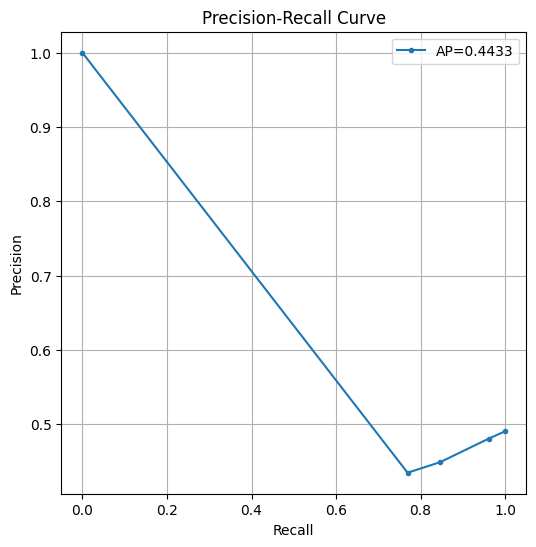

Optimal threshold (F1 max): 0.75


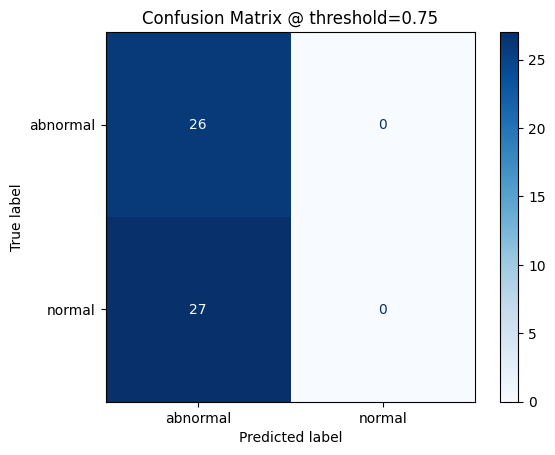

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

# abnormal = positive class
df['y_true'] = df['truth'].apply(lambda x: 1 if x=='abnormal' else 0)
y_true = df['y_true'].values
y_scores = df['confidence'].values

# Precision-Recall + AP
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"AP (mAP): {ap:.4f}")

# PR curve 시각화
plt.figure(figsize=(6,6))
plt.plot(recall, precision, marker='.', label=f'AP={ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# 최적 threshold 선택 (F1 최대)
f1_scores = 2*precision*recall/(precision+recall+1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (F1 max): {best_threshold:.2f}")

# Confusion matrix
y_pred = (y_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[1,0])
disp = ConfusionMatrixDisplay(cm, display_labels=['abnormal', 'normal'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix @ threshold={best_threshold:.2f}')
plt.show()
